# Word Sense Disambiguation (SemEval-2026 Task 5) - Group 02 Final Submission

In this final project submission, we present our complete machine learning pipeline for SemEval-2026 Task 5. Our goal is to predict continuous plausibility ratings for ambiguous word senses within short narrative contexts.

Through extensive experimentation, we identified that our best performing approach utilizes a flat **DeBERTa-v3-base** architecture combined with a **Multi-Objective Loss Function** (Huber, RankNet, and Uncertainty-Aware Margin). This effectively balances predictive accuracy with relative ranking (Spearman correlation). Additionally, we implement post-training **Nelder-Mead Threshold Optimization** to maximize our discrete Macro F1 score classification.

## Step 1: Environment Setup and Seed Initialization

First, we install our necessary dependencies and meticulously set up a global random seed. Setting a deterministic seed across Python, NumPy, and PyTorch ensures that our results are perfectly reproducible for evaluation.


In [1]:
!pip install transformers scikit-learn pandas scipy


In [2]:
import json
import copy
import warnings
import os
import random
from pathlib import Path
from dataclasses import dataclass
from typing import Any

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from scipy.optimize import minimize
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

def set_seed(seed=42):
    """Sets the seed for entire pipeline for reproducibility."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Ensure deterministic behavior in PyTorch
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


Device: cuda


## Step 2: Data Loading and Flat Concatenation

Our dataset consists of 5-sentence stories where the last sentence can retroactively change the meaning of the preceding sentences. To allow our model to cross-attend between all parts of the narrative simultaneously, we concatenate the precontext, sentence, ending, and target meaning into a single string separated by `[SEP]` tokens.

We construct our custom PyTorch `Dataset` and `DataLoader` classes to handle this process. The data is parsed correctly from dictionaries into lists to prevent indexing errors during batching.


In [3]:
MODEL_NAME = "microsoft/deberta-v3-base"

def build_tokenizer():
    return AutoTokenizer.from_pretrained(MODEL_NAME)

class AmbiStoryDataset(Dataset):
    def __init__(self, path):
        with Path(path).open("r", encoding="utf-8") as f:
            raw = json.load(f)

        # Parse from dictionary to list properly
        items = sorted(raw.items(), key=lambda x: int(x[0])) if isinstance(raw, dict) else [(str(i), s) for i, s in enumerate(raw)]

        self.records = []
        for sid, s in items:
            self.records.append({
                "precontext": str(s["precontext"]), "sentence": str(s["sentence"]),
                "ending": "" if s["ending"] is None else str(s["ending"]),
                "meaning": str(s["judged_meaning"]),
                "target_score": float(s["average"]), "target_stdev": float(s["stdev"]),
            })

    def __len__(self): return len(self.records)
    def __getitem__(self, i): return self.records[i]

@dataclass
class Collator:
    tokenizer: Any
    def __call__(self, examples):
        sep = self.tokenizer.sep_token or "[SEP]"

        # Flat concatenation of narrative components
        texts = [f"{e['precontext']} {sep} {e['sentence']} {sep} {e['ending']} {sep} {e['meaning']}" for e in examples]
        enc = self.tokenizer(texts, padding="longest", truncation=True, max_length=512, return_tensors="pt")

        return {
            "input_ids": enc["input_ids"].long(),
            "attention_mask": enc["attention_mask"].long(),
            "target_score": torch.tensor([e["target_score"] for e in examples], dtype=torch.float32),
            "target_stdev": torch.tensor([e["target_stdev"] for e in examples], dtype=torch.float32),
        }

def build_loaders(tokenizer, data_dir, batch_size=32):
    collator = Collator(tokenizer)
    train = DataLoader(AmbiStoryDataset(data_dir / "train.json"), batch_size=batch_size, shuffle=True, collate_fn=collator)
    dev = DataLoader(AmbiStoryDataset(data_dir / "dev.json"), batch_size=batch_size, shuffle=False, collate_fn=collator)
    return train, dev


We choose a batch size of 32 to give our RankNet loss function enough sample pairs to compare in each batch, which is crucial for learning relative rankings.

## Step 3: Model Architecture

We use `microsoft/deberta-v3-base` as our foundation model. Through prior iterations, we discovered that fully fine-tuning a base model yields much better results than using parameter-efficient fine-tuning on a larger model.

We extract the `[CLS]` token embedding, which acts as a summary of the entire concatenated narrative, and pass it through a custom regression head with Dropout. Importantly, we do NOT clamp the outputs using sigmoids, allowing the regression head to output raw continuous scores natively.


In [4]:
class WSDModel(nn.Module):
    def __init__(self):
        super().__init__()
        print(f"Loading {MODEL_NAME}...")
        self.encoder = AutoModel.from_pretrained(MODEL_NAME).float()
        hidden = self.encoder.config.hidden_size
        print(f"Encoder: {sum(p.numel() for p in self.encoder.parameters()):,} params, hidden={hidden}")

        # Raw linear regression head with 10% dropout
        self.head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, 1)
        )

    def forward(self, batch):
        out = self.encoder(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])

        # [CLS] token pooling
        cls = out.last_hidden_state[:, 0, :]
        return self.head(cls).squeeze(-1)


## Step 4: Multi-Objective Loss and Evaluation Metrics

Because our task involves both continuous plausibility and discrete classes, standard Mean Squared Error is insufficient. We design a `MultiObjectiveLoss` that computes:
1. **Huber Loss** for robustness against outliers.
2. **RankNet Loss** to optimize the pairwise ranking and drastically improve Spearman correlation.
3. **Uncertainty-Aware Margin** to penalize errors more heavily when human annotators were highly confident.

We also establish our lenient `Accuracy@std` calculation logic and basic evaluation pipelines here.


In [5]:
class RankNetLoss(nn.Module):
    def __init__(self, margin=0.0):
        super().__init__()
        self.margin = margin

    def forward(self, preds, tgts):
        p, t = preds.view(-1), tgts.view(-1)
        mask = (t.unsqueeze(1) - t.unsqueeze(0)) > self.margin
        if not mask.any(): return (p * 0.0).sum()
        return F.softplus(-(p.unsqueeze(1) - p.unsqueeze(0)))[mask].mean()

class UncertaintyLoss(nn.Module):
    def forward(self, preds, tgts, stds):
        return F.relu((preds.view(-1) - tgts.view(-1)).abs() - stds.view(-1).clamp(min=0)).mean()

class MultiObjectiveLoss(nn.Module):
    def __init__(self, lh=1.0, lr=0.5, lu=0.5):
        super().__init__()
        self.lh, self.lr, self.lu = lh, lr, lu
        self.huber = nn.HuberLoss(delta=1.0)
        self.rank = RankNetLoss()
        self.unc = UncertaintyLoss()

    def forward(self, preds, tgts, stds):
        h = self.huber(preds, tgts)
        r = self.rank(preds, tgts)
        u = self.unc(preds, tgts, stds)
        return {"loss": self.lh*h + self.lr*r + self.lu*u, "huber": h, "rank": r, "unc": u}

def clip_and_round(p):
    return np.clip(np.rint(np.asarray(p)), 1, 5).astype(int)

def evaluate_predictions(yt, yp, ys):
    yt, yp, ys = np.asarray(yt), np.clip(np.asarray(yp), 1, 5), np.asarray(ys)

    # Accuracy at standard deviation logic
    acc = np.mean(((yt - ys < yp) & (yp < yt + ys)) | (np.abs(yt - yp) < 1))

    sp, _ = spearmanr(yt, yp); sp = 0.0 if np.isnan(sp) else sp
    f1 = f1_score(clip_and_round(yt), clip_and_round(yp), average="macro", zero_division=0)

    return {"acc_std": acc, "spearman": sp, "f1": f1}

def plot_cm(yt, yp, normalize=True):
    labels = [1,2,3,4,5]
    cm = confusion_matrix(clip_and_round(yt), clip_and_round(yp), labels=labels)
    if normalize: cm = np.nan_to_num(cm.astype(float) / cm.sum(axis=1, keepdims=True)).round(2)
    fig, ax = plt.subplots(figsize=(6,5))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues")
    plt.title("Confusion Matrix (Row-Normalized)" if normalize else "Confusion Matrix")
    plt.show()


## Step 5: Training Loop

We configure the model to run for a maximum of 15 epochs, but we introduce an early stopping mechanism with a patience of 3 to halt training if our validation Spearman score stops improving.

We use differential learning rates: `2e-5` for the DeBERTa encoder to preserve its pre-trained knowledge, and `1e-3` for our randomly initialized regression head.


In [6]:
def run_training():
    print(f"Device: {device}")
    tokenizer = build_tokenizer()
    data_dir = Path("data")
    train_loader, dev_loader = build_loaders(tokenizer, data_dir, batch_size=32)

    model = WSDModel().to(device)
    enc_p = list(model.encoder.parameters())
    head_p = list(model.head.parameters())
    trainable = enc_p + head_p

    optimizer = optim.AdamW([
        {"params": enc_p, "lr": 2e-5},
        {"params": head_p, "lr": 5e-4},
    ], weight_decay=0.1)

    criterion = MultiObjectiveLoss(lh=1.0, lr=0.5, lu=0.5)

    epochs, patience = 20,5
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, total_steps // 10, total_steps)

    best_sp, best_state = -1, None
    no_improve = 0
    best_t, best_p, best_s = None, None, None

    for epoch in range(1, epochs + 1):
        model.train()
        tloss, nb_ = 0.0, 0
        for step, batch in enumerate(train_loader, 1):
            tgt = batch["target_score"].to(device)
            std = batch["target_stdev"].to(device)
            bd = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
            optimizer.zero_grad()

            pred = model(bd)
            ld = criterion(pred, tgt, std)
            ld["loss"].backward()

            torch.nn.utils.clip_grad_norm_(trainable, 1.0)
            optimizer.step(); scheduler.step()
            tloss += ld["loss"].item(); nb_ += 1
            if step % 20 == 0:
                print(f"  Epoch {epoch} | step {step:>3}/{len(train_loader)} | loss={tloss/nb_:.4f}")


        model.eval()
        all_t, all_p, all_s = [], [], []
        vloss, nb_v = 0.0, 0
        with torch.no_grad():
            for batch in dev_loader:
                tgt = batch["target_score"].to(device)
                std = batch["target_stdev"].to(device)
                bd = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
                p = model(bd)

                # Calculate validation loss
                ld = criterion(p, tgt, std)
                vloss += ld["loss"].item()
                nb_v += 1

                all_t.extend(batch["target_score"].numpy())
                all_p.extend(p.cpu().numpy())
                all_s.extend(batch["target_stdev"].numpy())

        m = evaluate_predictions(all_t, all_p, all_s)

        avg_train_loss = tloss / max(nb_, 1)
        avg_val_loss = vloss / max(nb_v, 1)

        print(f"\n  Epoch {epoch}/{epochs} -> Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Acc={m['acc_std']:.4f} Spear={m['spearman']:.4f} F1={m['f1']:.4f}")

        if m["spearman"] > best_sp:
            best_sp = m["spearman"]
            best_state = copy.deepcopy(model.state_dict())
            best_t, best_p, best_s = all_t, all_p, all_s
            no_improve = 0
            print(f"  >> New best Spearman: {best_sp:.4f} (saved)")
        else:
            no_improve += 1
            print(f"  >> No improvement ({no_improve}/{patience})")
            if no_improve >= patience:
                print(f"\nEarly stopping at epoch {epoch}.")
                break
        print()

    if best_state:
        model.load_state_dict(best_state)
        print(f"Restored best model (Spearman: {best_sp:.4f})")

    print("\nTraining Complete.")
    return model, dev_loader

model, dev_loader = run_training()


Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading microsoft/deberta-v3-base...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoder: 183,831,552 params, hidden=768
  Epoch 1 | step  20/72 | loss=3.1000
  Epoch 1 | step  40/72 | loss=2.2134
  Epoch 1 | step  60/72 | loss=1.8960

  Epoch 1/20 -> Train Loss: 1.7620 | Val Loss: 1.1890 | Acc=0.5612 Spear=0.1151 F1=0.1127
  >> New best Spearman: 0.1151 (saved)

  Epoch 2 | step  20/72 | loss=1.2001
  Epoch 2 | step  40/72 | loss=1.1354
  Epoch 2 | step  60/72 | loss=1.1033

  Epoch 2/20 -> Train Loss: 1.0858 | Val Loss: 1.0017 | Acc=0.6939 Spear=0.4296 F1=0.2318
  >> New best Spearman: 0.4296 (saved)

  Epoch 3 | step  20/72 | loss=0.8765
  Epoch 3 | step  40/72 | loss=0.8157
  Epoch 3 | step  60/72 | loss=0.8300

  Epoch 3/20 -> Train Loss: 0.8442 | Val Loss: 0.9684 | Acc=0.7041 Spear=0.4505 F1=0.1941
  >> New best Spearman: 0.4505 (saved)

  Epoch 4 | step  20/72 | loss=0.6265
  Epoch 4 | step  40/72 | loss=0.6214
  Epoch 4 | step  60/72 | loss=0.6372

  Epoch 4/20 -> Train Loss: 0.6421 | Val Loss: 0.9490 | Acc=0.7126 Spear=0.4732 F1=0.2434
  >> New best Spearm

## Step 6: Threshold Optimization & Final Evaluation

Finally, we apply **Nelder-Mead Threshold Optimization**. Since continuous scores rarely align perfectly with rigid integers, we programmatically search for the optimal decision boundaries using `scipy.optimize.minimize` to maximize our macro F1 score. We then output the confusion matrix utilizing our newly discovered, optimized classification boundaries.


Optimizing classification boundaries for F1 Score...
Default thresholds:  [1.5, 2.5, 3.5, 4.5] -> F1 = 0.2927
Optimal thresholds:  [1.51, 2.76, 3.43, 4.51] -> F1 = 0.3131
F1 improvement: +0.0204

Plotting final Confusion Matrix with Optimized Thresholds...


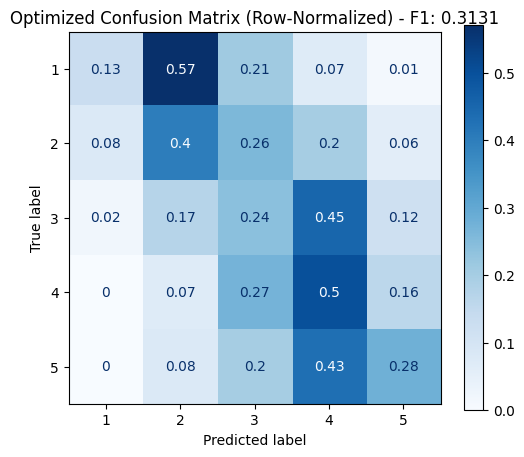

In [7]:
# Collect predictions from the best model
model.eval()
all_preds, all_trues, all_stds = [], [], []
with torch.no_grad():
    for batch in dev_loader:
        bd = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        p = model(bd)
        all_preds.extend(p.cpu().numpy())
        all_trues.extend(batch["target_score"].numpy())
        all_stds.extend(batch["target_stdev"].numpy())

preds = np.array(all_preds)
trues = np.array(all_trues)
stds = np.array(all_stds)

# Default rounding
default_rounded = clip_and_round(preds)
default_f1 = f1_score(clip_and_round(trues), default_rounded, average="macro", zero_division=0)

# Optimize thresholds using Nelder-Mead
def neg_f1(thresholds):
    t = sorted(thresholds)
    rounded = np.digitize(preds, t) + 1
    rounded = np.clip(rounded, 1, 5)
    return -f1_score(clip_and_round(trues), rounded, average="macro", zero_division=0)

print("Optimizing classification boundaries for F1 Score...")
result = minimize(neg_f1, [1.5, 2.5, 3.5, 4.5], method="Nelder-Mead")
best_thresholds = sorted(result.x)

# Apply optimal thresholds
optimized_rounded = np.clip(np.digitize(preds, best_thresholds) + 1, 1, 5)
optimized_f1 = f1_score(clip_and_round(trues), optimized_rounded, average="macro", zero_division=0)

print(f"Default thresholds:  [1.5, 2.5, 3.5, 4.5] -> F1 = {default_f1:.4f}")
print(f"Optimal thresholds:  [{best_thresholds[0]:.2f}, {best_thresholds[1]:.2f}, {best_thresholds[2]:.2f}, {best_thresholds[3]:.2f}] -> F1 = {optimized_f1:.4f}")
print(f"F1 improvement: +{optimized_f1 - default_f1:.4f}")

# Generate Heatmap
print("\nPlotting final Confusion Matrix with Optimized Thresholds...")
labels = [1, 2, 3, 4, 5]
cm = confusion_matrix(clip_and_round(trues), optimized_rounded, labels=labels)
cm_norm = np.nan_to_num(cm.astype(float) / cm.sum(axis=1, keepdims=True)).round(2)

fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)
disp.plot(cmap="Blues", ax=ax)
plt.title(f"Optimized Confusion Matrix (Row-Normalized) - F1: {optimized_f1:.4f}")
plt.show()
